# Karar Laboratuvarı 01 — Negatif Bulguyla Hedefi Kapatmak

**Ortak yazarlar:** Pusula (karar mantığı ve anlatı) · Rota (çalıştırılabilir analiz, montaj ve QA)  
**Kapsam:** `noter_devir_otomobil_adet` için iki ay gecikmeli, aylık, up/stable/down nowcast hattı  
**Durum:** Karar desteği; yeni deney değildir  
**Test:** 2025-07..2026-06 kilitli kalır

Bu notebook, “araç piyasası tahmin edilemez” sonucuna varmaz. Daha dar ve denetlenebilir bir soruyu yanıtlar: **Mevcut hedef tanımı, bilgi gecikmesi ve Model 09 feature temsiliyle yürütülen hattı sürdürmek için yeterli kanıt var mı?**

## Okuma hedefleri

Notebook sonunda okuyucu:

1. Model 09, 10 ve 11’in neden tek bir kanıt zinciri olduğunu açıklayabilir.
2. “Etki yoktur” ile “kullanılabilir beceri gösterilememiştir” ifadelerini ayırabilir.
3. Kapatma kararının kapsamını ve yeniden açma koşullarını yazılı hale getirebilir.
4. Kilitli teste bakmadan operasyonel durdurma kararı verebilir.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

def repo_kokunu_bul():
    baslangic = Path.cwd().resolve()
    for aday in [baslangic, *baslangic.parents]:
        if (aday / "README.md").exists() and (aday / "data").exists():
            return aday
    raise FileNotFoundError("Repo kökü bulunamadı. Notebook'u repo içinde çalıştırın.")

ROOT = repo_kokunu_bul()
MODEL_DIR = ROOT / "data" / "processed" / "model"

def json_oku(dosya_adi, fallback):
    yol = MODEL_DIR / dosya_adi
    if yol.exists():
        return json.loads(yol.read_text(encoding="utf-8")), f"canlı dosya: {yol.relative_to(ROOT)}"
    return fallback, f"raporda sabitlenmiş fallback: {dosya_adi}"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 100)
print("Repo:", ROOT)

Repo: C:\Users\YOGA\Desktop\araç piyasasında yön analizi için kullanılan yöntemler - Kopya - Kopya


In [2]:
M09_FALLBACK = {
    "en_iyi_baseline": "persistence_m_eksi_2",
    "en_iyi_baseline_metrikleri": {"mcc_gorodkin": 0.1099498743, "macro_f1": 0.4148148148},
    "validation_kazanan": "random_forest_sigin",
    "denemeler": {"random_forest_sigin": {"genel_validation": {"mcc_gorodkin": 0.0374429716, "macro_f1": 0.1886833633}}},
    "terfi_kapisi": {"gecti_mi": False},
    "test": "ACILMADI"
}
M10_FALLBACK = {
    "origin_sayisi": 50, "embargo_ay_sayisi": 2, "bootstrap_tekrar": 2000,
    "genel_metrikler": {
        "persistence_m_eksi_2": {"nokta": {"mcc": 0.0165080996}, "hareketli_blok4_ci95": {"mcc": [-0.1463801321, 0.2343857275]}},
        "seasonal_t_eksi_12": {"nokta": {"mcc": 0.0141027495}, "hareketli_blok4_ci95": {"mcc": [-0.1374875010, 0.2416403225]}},
        "lojistik_l2_c01": {"nokta": {"mcc": -0.0700457928}, "hareketli_blok4_ci95": {"mcc": [-0.2052866443, 0.0961187025]}},
        "lojistik_l2_c1": {"nokta": {"mcc": -0.0306037071}, "hareketli_blok4_ci95": {"mcc": [-0.1953999450, 0.1384886279]}},
        "random_forest_sigin": {"nokta": {"mcc": -0.1192726043}, "hareketli_blok4_ci95": {"mcc": [-0.2428229437, 0.0863564297]}},
        "hist_gradient_sigin": {"nokta": {"mcc": -0.1096731658}, "hareketli_blok4_ci95": {"mcc": [-0.2728550927, 0.1008672224]}}
    },
    "ci_yari_genislik_saptama_gucu_gostergesi": {"min": 0.21, "max": 0.28},
    "herhangi_terfi": False, "test": "ACILMADI_KILITLI"
}
M11_FALLBACK = {
    "bolum2_gecis_lag": {"lag_persistence": {"1": {"mcc": -0.0204081633, "mcc_ci95": [-0.2615107846, 0.1542392074]}}},
    "bolum4_oracle_bilgi_tavani": {"oracle_b": {
        "lojistik_l2_c01": {"tavan_gozlenen": 0.2147571548, "tavan_null95": 0.4450343896},
        "lojistik_l2_c1": {"tavan_gozlenen": 0.1689784848, "tavan_null95": 0.4683733695},
        "random_forest_sigin": {"tavan_gozlenen": 0.9168817091, "tavan_null95": 0.9155435039},
        "hist_gradient_sigin": {"tavan_gozlenen": 1.0, "tavan_null95": 1.0}}},
    "hukum": {"ateslenen": ["A_bilgi_kisiti"], "ham_bayraklar": {"C": False, "B": False, "D": False, "A": True}},
    "test": "2025-07..2026-06 ACILMADI_KILITLI"
}
m09, kaynak09 = json_oku("model_09_dusuk_kapasiteli_nowcast_validation.json", M09_FALLBACK)
m10, kaynak10 = json_oku("model_10_rolling_origin_ozet.json", M10_FALLBACK)
m11, kaynak11 = json_oku("model_11_hedef_teshis_ozet.json", M11_FALLBACK)
pd.DataFrame({"aşama":["Model 09","Model 10","Model 11"], "kaynak":[kaynak09,kaynak10,kaynak11]})

,aşama,kaynak
0,Model 09,canlı dosya: data\processed\model\model_09_dusuk_kapasiteli_nowcast_validation.json
1,Model 10,canlı dosya: data\processed\model\model_10_rolling_origin_ozet.json
2,Model 11,canlı dosya: data\processed\model\model_11_hedef_teshis_ozet.json


## Üç aşamalı kanıt zinciri

- **Model 09**, tek doğrulama bloğunda düşük kapasiteli adayları güçlü ve basit kurallarla karşılaştırdı. En iyi model, M−2 persistence baseline’ını hem MCC hem macro-F1’da geçemedi.
- **Model 10**, tek blok sonucunun döneme özgü olma riskini 50 rolling-origin ve blok bootstrap ile sınadı. Persistence MCC’si 0.110’dan 0.0165’e geriledi; hiçbir model terfi kapısını geçmedi.
- **Model 11**, başarısızlığın yalnız algoritma seçimi olup olmadığını araştırdı. Etiket gecikmelerinde güvenilir bağ ve mevcut feature temsilinde permütasyon null’ını maddi marjla aşan oracle tavanı bulunmadı.

Bu sıra önemlidir: önce performans ölçüldü, sonra zaman içindeki dayanıklılık sınandı, en son bilgi/temsil tavanı teşhis edildi.

In [3]:
m09_rf = m09["denemeler"]["random_forest_sigin"]["genel_validation"]
m10_p = m10["genel_metrikler"]["persistence_m_eksi_2"]
lag1 = m11["bolum2_gecis_lag"]["lag_persistence"]["1"]
kanit_zinciri = pd.DataFrame([
    ["Model 09", "Tek doğrulama bloğu", m09["en_iyi_baseline_metrikleri"]["mcc_gorodkin"], "RF MCC=%.3f; baseline geçilmedi" % m09_rf["mcc_gorodkin"]],
    ["Model 10", "50 rolling origin", m10_p["nokta"]["mcc"], "Blok4 CI [%.3f, %.3f]" % tuple(m10_p["hareketli_blok4_ci95"]["mcc"])],
    ["Model 11", "Lag + oracle teşhisi", lag1["mcc"], "Lag-1 CI [%.3f, %.3f]; A bilgi kısıtı" % tuple(lag1["mcc_ci95"])],
], columns=["aşama","tasarım","MCC referansı","hüküm"])
kanit_zinciri

,aşama,tasarım,MCC referansı,hüküm
0,Model 09,Tek doğrulama bloğu,0.109950,RF MCC=0.037; baseline geçilmedi
1,Model 10,50 rolling origin,0.016508,"Blok4 CI [-0.146, 0.234]"
2,Model 11,Lag + oracle teşhisi,-0.020408,"Lag-1 CI [-0.262, 0.154]; A bilgi kısıtı"


## Güç ve belirsizlik: “yok” demek neden yasak?

Model 10’daki ΔMCC çözünürlük yarı genişliği yaklaşık 0.21–0.28’dir. Bu genişlik, küçük/orta etkileri kesin biçimde sıfırdan ayırmak için örneklemin sınırlı olduğunu gösterir. Dolayısıyla bilimsel ifade **“etki kesinlikle yoktur”** değildir.

Operasyonel karar daha farklıdır: ön-kayıtlı terfi eşiğini geçen, işaretini yıllar arasında koruyan veya mevcut bilgi temsilinde null üstüne maddi marj koyan bir aday yoktur. Projeyi bu tanımla durdurmak, yokluk teoremi değil **kanıt standardını geçemeyen hattı finanse etmeme kararıdır**.

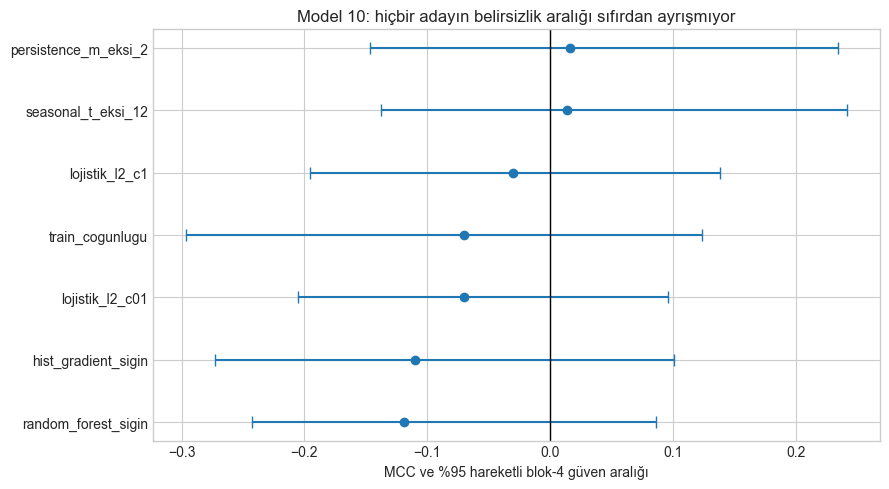

In [4]:
satirlar = []
for ad, deger in m10["genel_metrikler"].items():
    satirlar.append({
        "aday": ad,
        "mcc": deger["nokta"]["mcc"],
        "alt": deger["hareketli_blok4_ci95"]["mcc"][0],
        "üst": deger["hareketli_blok4_ci95"]["mcc"][1],
    })
mcc_df = pd.DataFrame(satirlar).sort_values("mcc")
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    mcc_df["mcc"], range(len(mcc_df)),
    xerr=[mcc_df["mcc"]-mcc_df["alt"], mcc_df["üst"]-mcc_df["mcc"]],
    fmt="o", capsize=4
)
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(range(len(mcc_df)), mcc_df["aday"])
ax.set_xlabel("MCC ve %95 hareketli blok-4 güven aralığı")
ax.set_title("Model 10: hiçbir adayın belirsizlik aralığı sıfırdan ayrışmıyor")
plt.tight_layout()
plt.show()

## Bilgi tavanı: yüksek ezber skoru neden beceri değildir?

Oracle-B modelleri değerlendirme aylarının gerçek etiketleriyle bilerek in-sample fit edildi. Bu dürüst bir tahminciye verilmeyen avantajdır. Yine de sonuç yalnız kendi permütasyon null’ıyla kıyaslanır. Random Forest’ın gözlenen-null farkı yaklaşık 0.0013, HGB’nin farkı 0’dır; ön-kayıtlı maddi marj **0.15** idi.

Bu nedenle 0.917 veya 1.000 gibi yüksek ham skorlar “öngörü gücü” değildir. Aynı model, etiketler permüte edildiğinde de hemen aynı ezberi üretmiştir.

In [5]:
oracle = m11["bolum4_oracle_bilgi_tavani"]["oracle_b"]
oracle_df = pd.DataFrame([
    [ad, v["tavan_gozlenen"], v["tavan_null95"],
     v["tavan_gozlenen"]-v["tavan_null95"],
     (v["tavan_gozlenen"]-v["tavan_null95"]) >= 0.15]
    for ad, v in oracle.items()
], columns=["aday","gözlenen_tavan","null95","marj","marj_en_az_0_15"])
oracle_df

,aday,gözlenen_tavan,null95,marj,marj_en_az_0_15
0,lojistik_l2_c01,0.214757,0.445034,-0.230277,False
1,lojistik_l2_c1,0.168978,0.468373,-0.299395,False
2,random_forest_sigin,0.916882,0.915544,0.001338,False
3,hist_gradient_sigin,1.000000,1.000000,0.000000,False


## Yanlış yorumlama kontrol listesi

- Negatif MCC, modelin sistematik biçimde “tersini bildiği” anlamına gelmez; rejim ve sınıf önseli kayması bu sonucu üretebilir.
- Güven aralığının sıfırı içermesi, etkinin kesinlikle sıfır olduğunu kanıtlamaz.
- ±%10 bandında görülen seasonal MCC=0.158 post-hoc bulgudur; ön-kayıtlı kapıyı geçmez ve kapatma/açma gerekçesi olamaz.
- Kapatma hükmü yalnız mevcut hedef + gecikme + ufuk + feature temsili içindir; tüm otomobil piyasası sinyallerine genellenemez.

## Karar kapısı

Bu seçenek aşağıdaki dört koşul birlikte kayda geçtiğinde savunulabilir:

1. Model 09 ve 10’da ön-kayıtlı terfi yoktur.
2. Model 11’de mevcut temsilin oracle tavanı null95 üzerine ≥0.15 marj koyamamıştır.
3. Model 11 hükmünde B (yalnız bilgi gecikmesi) ve D (yalnız stable-band tanımı) açıklamaları da elenmiş; kalan hüküm A bilgi kısıtı olmuştur.
4. Kilitli test, başarısız geliştirme kararını “kurtarmak” için açılmamıştır.
5. Karar cümlesi evrensel değil kapsamlıdır: “mevcut temsil ve hedef sözleşmesiyle hat durdurulmuştur.”

**Yeniden açma koşulu:** Seçenek 2 kapsamında as-of uyumlu, mevcut temsilin kapsamadığı bir öncü bilgi ailesi için ön-kayıtlı tavan testi veya Seçenek 3 kapsamında kullanıcı tarafından onaylanmış yeni hedef sözleşmesi. Bunlar gerçekleşmeden beşinci algoritmayı denemek yeniden açma sayılmaz.

## Ortak karar puanlama şeması

Üç seçenek aynı dört eksende 0–3 puanlanır. Bu tablo otomatik kazanan üretmez; puan ile gerekçenin birlikte kaydedilmesini zorunlu kılar.

| Eksen | 0 puan | 3 puan |
|---|---|---|
| Kanıt gücü | Spekülasyon | Model 09→10→11 zincirinin doğrudan sonucu |
| Maliyet / tersinirlik | K değişikliği, yeni ön-kayıt ve/veya yeni kaynak | Yalnız dokümantasyon; karar geri alınabilir |
| Belirsizlik azaltımı | Yeni ve büyük bir açık soru seti doğurur | Mevcut açık soruyu kapatır |
| Kapsam sadakati | Sabit hedef/sınıf/ufuk kararını değiştirir | Sabitlerin hiçbirine dokunmaz |

Puanlar tek başına karar değildir. Her puanın yanına kanıt referansı yazılmadan toplam alınmamalıdır.

In [6]:
puanlama_sablonu = pd.DataFrame(
    [
        ["1 — hedefi kapat", pd.NA, pd.NA, pd.NA, pd.NA, ""],
        ["2 — bilgi kümesini genişlet", pd.NA, pd.NA, pd.NA, pd.NA, ""],
        ["3 — ufuk/toplulaştırma/sınıf değiştir", pd.NA, pd.NA, pd.NA, pd.NA, ""],
    ],
    columns=["seçenek", "kanıt_gücü_0_3", "maliyet_tersinirlik_0_3",
             "belirsizlik_azaltımı_0_3", "kapsam_sadakati_0_3", "kanıt_gerekçesi"],
)
puanlama_sablonu

,seçenek,kanıt_gücü_0_3,maliyet_tersinirlik_0_3,belirsizlik_azaltımı_0_3,kapsam_sadakati_0_3,kanıt_gerekçesi
0,1 — hedefi kapat,<NA>,<NA>,<NA>,<NA>,
1,2 — bilgi kümesini genişlet,<NA>,<NA>,<NA>,<NA>,
2,3 — ufuk/toplulaştırma/sınıf değiştir,<NA>,<NA>,<NA>,<NA>,


## Sonuç

Bu notebook nihai kararı ilan etmez. Negatif bulguyla kapatmanın **ne anlama geldiğini, hangi kanıta dayandığını ve hangi koşulda geri alınabileceğini** denetlenebilir hale getirir. Nihai seçim proje sahibine aittir.